# Example Notebook

We will use the data obtained characterising the dipole moment in a MoSe2/WSe2 heterostructure.

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import tmdc_optics_tools as tmdc
import os
from cmcrameri import cm  
from pathlib import Path
import matplotlib.animation as animation

We load our sample geometry. We define our measured our top and bottom hBN thicknesses. Defining the sample will be important for the calculation of the electric field inside the heterostructure.

In [2]:
sample_geometry = tmdc.DeviceGeometry(
    tmdc_stack = [
        tmdc.StackLayer("MoSe2"),
        tmdc.StackLayer("WSe2"),
    ],
    d_hbn_top = 53, # in nm
    d_hbn_bottom = 46, # in nm
)

Load the file of interest and call our data loader. For this measurement, we used a voltage scan of the top and bottom contacts to generate an electric field within the heterostructure. We pass our sample geometry into this data loader to automatically calculate the electric field applied.

In [3]:
filename = "PL-dual-gate-sweep_26_05_15_14_03_18_iter_0.csv"

scan = tmdc.AttoCubePLVabScan(
    os.path.join("./data/", filename),
    geometry=sample_geometry,
    top_gate_label = "V_A",
    bot_gate_label = "V_B",
    ich2_label = "I_A",
    ich1_label = "I_B",
    apply_jacobian = True,     # For transformation of PL intensity in nm [I(lambda)] to PL intensity in eV [I(eV)].
    bg_region_eV = (1.42,1.44) # For background subtraction. Must be used if apply_jacobian = True
    )
print(scan)

AttoCubePLVabScan — 61 sweeps × 1340 pixels
  File       : ./data/PL-dual-gate-sweep_26_05_15_14_03_18_iter_0.csv
  λ range    : 868.6 – 989.9 nm  (1.252 – 1.427 eV)
  V_top      : -17.3 → 17.3 V
  V_bot      : -15.0 → 15.0 V
  E_F        : -172.0 → 172.0 mV/nm
  BG region  : 861.0 – 873.1 nm
  Jacobian   : applied



We have a number of properties of the variable `scan` which we can access and manipulate manually if we wish. Now we can call our plotting function to show our PL spectra as a function of applied electric field.

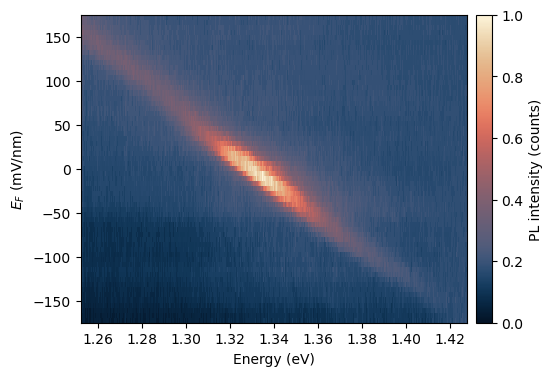

In [4]:
fig, ax, mesh = tmdc.plotting.plot_pl_map_Vab_scan(
    scan = scan,
    cmap = "lipari",
)

Another quantity of interest for us is the dipole length of the interlayer exciton. This can be calculated easily through. The `dipole_fit` variable is part of the `DipoleResult`. Running `print(dipole_fit)` will return some of the quantites of interest for us.

In [5]:
dipole_fit = tmdc.fitting.extract_dipole_length(
    scan     = scan,
    x_range  = (1.30, 1.38),
    model    = "lorentzian",
    bg_region = (1.40, 1.42),           # flat region on high-energy side
    Efield_range = (-75, 75),           # in mV/nm
)

print(dipole_fit)

DipoleResult
  Dipole length : 0.2732 ± 0.0042 nm  (2.73 Å)
  Slope dE/dF   : -2.7316e-04 ± 4.17e-06 eV/(mV/nm)
  Intercept E₀  : 1.3146 ± 0.0001 eV
  R²            : -2.1565
  Peak model    : lorentzian
  Sweep points  : 27 / 61 converged


We can also plot how the peak of PL energy shifts with applied electric field.

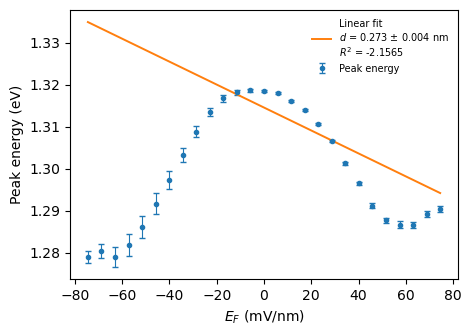

In [6]:
fig, ax = tmdc.plotting.plot_stark_shift(
    dipole_result = dipole_fit,
)

## Generating custom figures

So far running our plot commands generates one figure. We can instead create an existing set of axes in matplotlib and use those instead of creating new ones each time we run the function. Doing this allows us to manipulate our figures in a more precise way. For our dipole length plot, we could also do

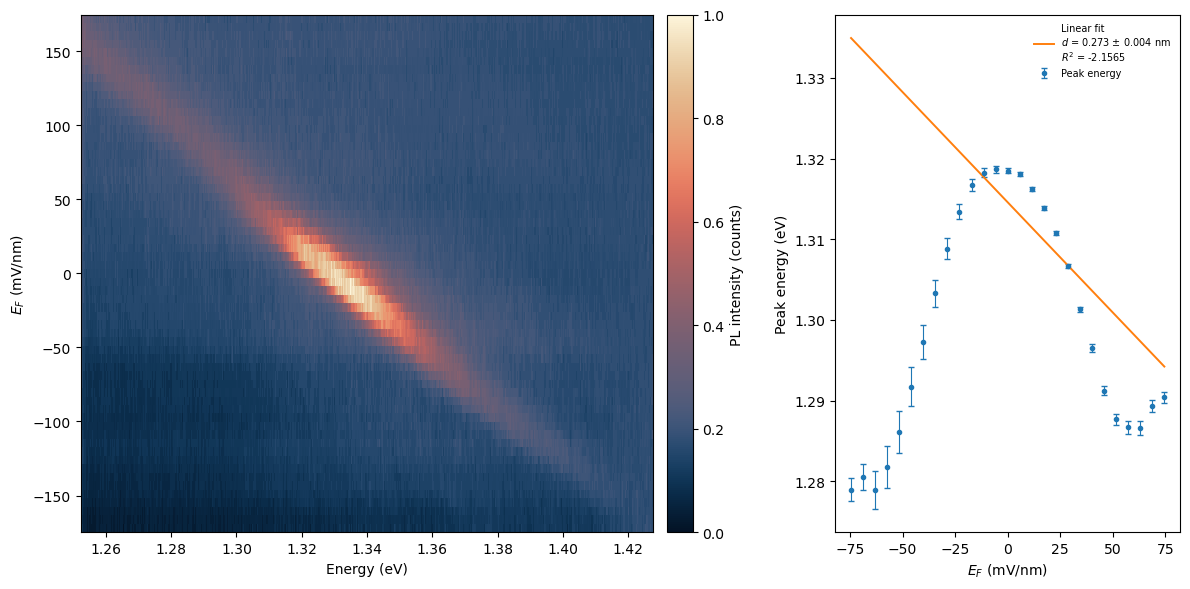

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 6), gridspec_kw={"width_ratios": [2, 1]})

tmdc.plotting.plot_pl_map_Vab_scan(
    scan = scan,
    ax   = axes[0],
    cmap = "lipari"
)

tmdc.plotting.plot_stark_shift(
    dipole_result = dipole_fit,
    ax            = axes[1],
)

fig.tight_layout()

## Referencing laser spot on the sample

Another commonly required task is locating the laser spot on the sample being measured. For this to be done, we require two images: an image of the laser spot incident on the sample, and an image of the sample illuminated with whitelight such that it is visible to us.

We load our image containing the laser spot.

In [8]:
laser_reference_image = tmdc.loaders.AttoCubeLaserReferenceImage(
    path = "./data/" + "/laser_26_05_15_14_04_45.csv")

We can show our image

(<Figure size 640x480 with 1 Axes>, <Axes: >)

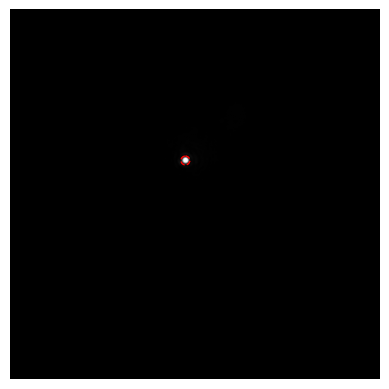

In [9]:
laser_reference_image.show_image(laser_annotation=True)

and we can also extract the data for our laser spot

In [10]:
print(laser_reference_image)

AttoCubeLaserReferenceImage
  File                  : ./data//laser_26_05_15_14_04_45.csv
  Center                : (242.4, 208.8) px
  Estimated 1/e² Radius : 6.1 px
  Estimated 1/e² Diameter: 12.3 px


With the parameters of our laser spot, we can now place the location of the laser spot on our sample image. To do so, we pass our `laser_reference_image` variable into the data loader for our sample reference image.

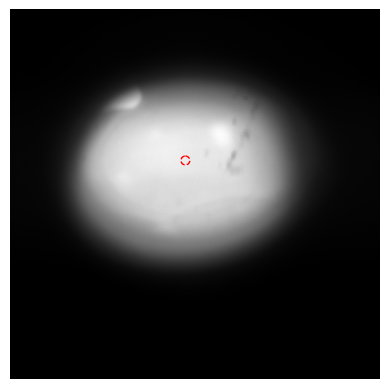

In [11]:
sample_reference_image = tmdc.loaders.AttoCubeSampleImage(
    path= "./data/" + "/wl_image_26_05_15_14_04_57.csv",
    laser_ref = laser_reference_image)

fig, ax = sample_reference_image.show_image(laser_annotation=True)

## Animated gif of real-space PL map

There are other times where we are interested in how the real-space PL map evolves as a function of some parameter we apply to the sample (e.g. electric field, optical excitation power).

The files in the AttoCube setup are generated with the following naming convention: `prefix` + `_iter_N.csv` where `N` is the image number. In our example here, we restrict ourselves to the first 11 real-space images due to data size constraints.

In [12]:
real_space_PL_map =  tmdc.loaders.AttoCubePLScanRealSpace(
    path = "./data/",
    prefix = "PL-dual-gate-sweep",
    geometry = sample_geometry,
    laser_ref = laser_reference_image
)

print(f"We have {real_space_PL_map.n_frames} frames in the real-space PL map.")

We have 11 frames in the real-space PL map.


Then we can call our function to animate the images.

As a note, the function `animate_real_space_PL_map` accepts more arguments,

``` python
fig, anim = tmdc.plotting.animate_real_space_PL_map(
    scan = real_space_PL_map,
    laser_annotation = True,
    var_array        = "array-like,
    var_label        : str  = "Ez",
    units            : str  = "mV/nm",
)
```

which allow each frame to be titled with the quantity being investigated. In our example, we use the electric field.

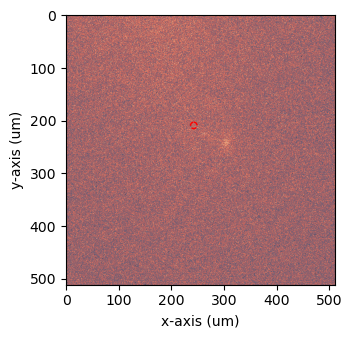

In [13]:
fig, anim = tmdc.plotting.animate_real_space_PL_map(
    scan = real_space_PL_map,
    laser_annotation = True,
    cmap = "lipari",
)

# interval_ms = 100
# anim.save("photoluminescence_sweep_laser_spot.gif", writer="pillow", fps=1000 / interval_ms)